# **Enable GPU and check environment**

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
Using: cuda


# **Install packages & Imports**

In [ ]:
!pip -q install torchmetrics[image] scipy tqdm pandas matplotlib
import os
import math
import time
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

from torchmetrics.image.fid import FrechetInceptionDistance

print("All imports successful.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.8 MB/s eta 0:00:00
All imports successful.


# **Reproducibility**

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


# **Configuration**

In [ ]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

IMAGE_SIZE = 28
CHANNELS = 1

BATCH_SIZE = 128

TRAINING_STEPS = 30000

LEARNING_RATE = 2e-4

BASE_CHANNELS = 64

SIGMA_MIN = 0.01
SIGMA_MAX = 5.0

SAMPLING_STEPS = [
    50,
    100,
    250,
    500,
    1000
]

FID_NUM_IMAGES = 1000
CLASSIFIER_NUM_IMAGES = 1000

print("Training steps:", TRAINING_STEPS)
print("Sigma min:", SIGMA_MIN)
print("Sigma max:", SIGMA_MAX)
print("Sampling steps:", SAMPLING_STEPS)

Training steps: 30000
Sigma min: 0.01
Sigma max: 5.0
Sampling steps: [50, 100, 250, 500, 1000]


# **Download MNIST**

In [ ]:
DATA_DIR = "/content/data"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 461kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.11MB/s]

Training images: 60000
Test images: 10000


# **Display MNIST images**

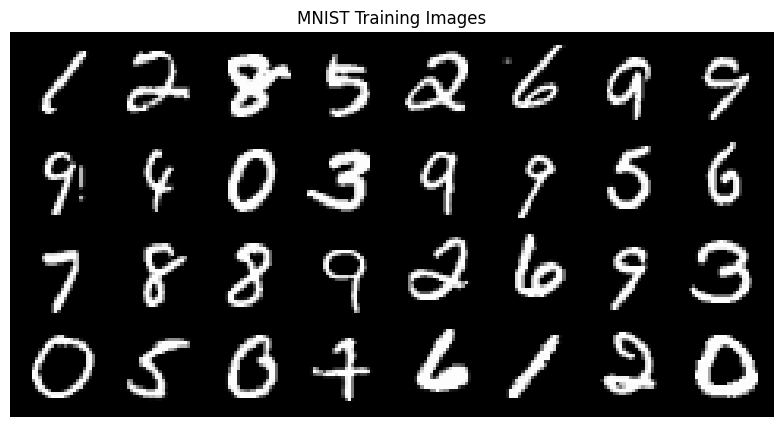

In [ ]:
loader_preview = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(loader_preview))

grid = make_grid(
    images,
    nrow=8,
    normalize=True,
    value_range=(-1, 1)
)

plt.figure(figsize=(10, 5))

plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)

plt.axis("off")
plt.title("MNIST Training Images")

plt.show()

# **Training DataLoader**

In [ ]:
TRAIN_SUBSET_SIZE = len(train_dataset)

if TRAIN_SUBSET_SIZE < len(train_dataset):

    indices = torch.randperm(
        len(train_dataset)
    )[:TRAIN_SUBSET_SIZE]

    train_data = Subset(
        train_dataset,
        indices.tolist()
    )

else:
    train_data = train_dataset

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print(
    "Training samples:",
    len(train_data)
)

Training samples: 60000


# **Define VE-SDE**


In [ ]:
class VESDE:

    def __init__(
        self,
        sigma_min=0.01,
        sigma_max=5.0
    ):
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def sigma(self, t):

        return (
            self.sigma_min
            *
            (
                self.sigma_max /
                self.sigma_min
            ) ** t
        )

    def marginal_prob(
        self,
        x,
        t
    ):

        sigma = self.sigma(t)

        mean = x
        std = sigma

        return mean, std

    def prior_sampling(
        self,
        shape,
        device
    ):

        return (
            torch.randn(
                shape,
                device=device
            )
            *
            self.sigma_max
        )

    def diffusion(self, t):

        return (
            self.sigma(t)
            *
            math.sqrt(
                2 *
                math.log(
                    self.sigma_max /
                    self.sigma_min
                )
            )
        )


sde = VESDE(
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX
)

print("VE-SDE ready.")
print("sigma_min =", sde.sigma_min)
print("sigma_max =", sde.sigma_max)

VE-SDE ready.
sigma_min = 0.01
sigma_max = 5.0


# **Test the noise**

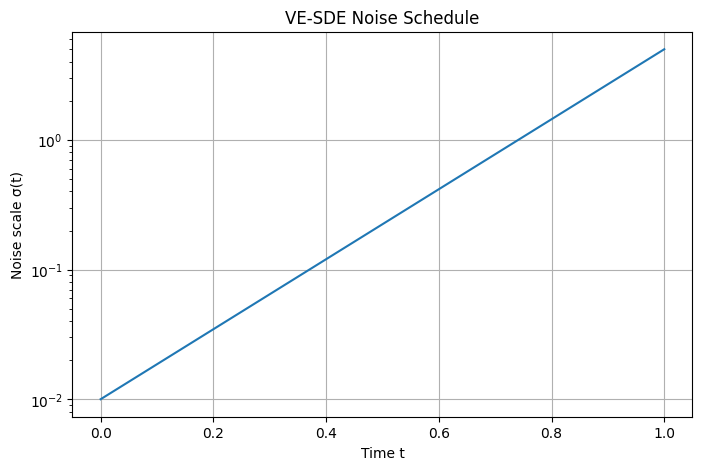

In [ ]:
t_test = torch.linspace(
    0.0,
    1.0,
    100
)

sigma_test = sde.sigma(t_test)

plt.figure(figsize=(8, 5))

plt.semilogy(
    t_test.numpy(),
    sigma_test.numpy()
)

plt.xlabel("Time t")
plt.ylabel("Noise scale σ(t)")
plt.title("VE-SDE Noise Schedule")

plt.grid(True)

plt.show()

# **Time embedding**

In [ ]:
# ============================================================
# TIME EMBEDDING
# ============================================================

class GaussianFourierProjection(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        scale=30.0
    ):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(
                embed_dim // 2
            ) * scale,
            requires_grad=False
        )

    def forward(self, x):

        x_proj = (
            x[:, None]
            *
            self.W[None, :]
            *
            2
            *
            math.pi
        )

        return torch.cat(
            [
                torch.sin(x_proj),
                torch.cos(x_proj)
            ],
            dim=-1
        )

# **Score Network**

In [ ]:
# ============================================================
# U-NET SCORE NETWORK
# ============================================================

class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()


        self.norm1 = nn.GroupNorm(
            8,
            in_channels
        )

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )


        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )


        self.time_proj = nn.Linear(
            time_dim,
            out_channels
        )


        if in_channels != out_channels:

            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.skip = nn.Identity()


    def forward(
        self,
        x,
        t_emb
    ):

        h = self.norm1(x)

        h = F.silu(h)

        h = self.conv1(h)


        # Add time information
        time_term = self.time_proj(
            t_emb
        )

        h = (
            h
            +
            time_term[
                :,
                :,
                None,
                None
            ]
        )


        h = self.norm2(h)

        h = F.silu(h)

        h = self.conv2(h)


        return h + self.skip(x)


# ============================================================
# SMALL U-NET
# ============================================================

class UNetScoreNet(nn.Module):

    def __init__(
        self,
        base_channels=64
    ):

        super().__init__()


        time_dim = 128


        # ----------------------------------------------------
        # Time embedding
        # ----------------------------------------------------

        self.time_embed = (
            GaussianFourierProjection(
                embed_dim=128,
                scale=16.0
            )
        )


        self.time_mlp = nn.Sequential(

            nn.Linear(
                128,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )


        # ----------------------------------------------------
        # Input
        # ----------------------------------------------------

        self.input_conv = nn.Conv2d(
            1,
            base_channels,
            kernel_size=3,
            padding=1
        )


        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.enc1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )


        self.down1 = nn.Conv2d(
            base_channels,
            base_channels * 2,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.enc2 = ResBlock(
            base_channels * 2,
            base_channels * 2,
            time_dim
        )


        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 2,
            time_dim
        )


        self.mid2 = ResBlock(
            base_channels * 2,
            base_channels * 2,
            time_dim
        )


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )


        self.dec1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )


        # ----------------------------------------------------
        # Output
        # ----------------------------------------------------

        self.output_norm = nn.GroupNorm(
            8,
            base_channels
        )


        self.output_conv = nn.Conv2d(
            base_channels,
            1,
            kernel_size=3,
            padding=1
        )


        # ----------------------------------------------------
        # Initialize output close to zero
        # ----------------------------------------------------

        nn.init.zeros_(
            self.output_conv.weight
        )

        nn.init.zeros_(
            self.output_conv.bias
        )


    def forward(
        self,
        x,
        t
    ):

        # ----------------------------------------------------
        # Time embedding
        # ----------------------------------------------------

        t_emb = self.time_embed(t)

        t_emb = self.time_mlp(
            t_emb
        )


        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        x0 = self.input_conv(x)


        e1 = self.enc1(
            x0,
            t_emb
        )


        e2_input = self.down1(
            e1
        )


        e2 = self.enc2(
            e2_input,
            t_emb
        )


        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        h = self.mid1(
            e2,
            t_emb
        )

        h = self.mid2(
            h,
            t_emb
        )


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        h = self.up1(
            h
        )


        # ----------------------------------------------------
        # Handle possible size difference
        # ----------------------------------------------------

        if h.shape[-2:] != e1.shape[-2:]:

            h = F.interpolate(
                h,
                size=e1.shape[-2:],
                mode="bilinear",
                align_corners=False
            )


        # Skip connection
        h = torch.cat(
            [
                h,
                e1
            ],
            dim=1
        )


        h = self.dec1(
            h,
            t_emb
        )


        # ----------------------------------------------------
        # Output
        # ----------------------------------------------------

        h = self.output_norm(h)

        h = F.silu(h)

        h = self.output_conv(h)


        return h

# **Create model**

In [ ]:
# ============================================================
# CREATE NEW U-NET SCORE MODEL
# ============================================================

model = UNetScoreNet(
    base_channels=BASE_CHANNELS
).to(device)


num_parameters = sum(
    p.numel()
    for p in model.parameters()
)


print(
    "U-Net Score Network created."
)

print(
    "Parameters:",
    f"{num_parameters:,}"
)

print(
    "Device:",
    device
)

U-Net Score Network created.
Parameters: 1,385,985
Device: cuda


# **Score matching loss**

In [ ]:
def score_matching_loss(
    model,
    x,
    sde
):

    batch_size = x.shape[0]


    # Random time
    t = (
        torch.rand(
            batch_size,
            device=x.device
        )
        * 0.999
        + 0.001
    )


    # Gaussian noise
    z = torch.randn_like(x)


    # Noise level
    sigma = sde.sigma(t)


    sigma_view = sigma[
        :,
        None,
        None,
        None
    ]


    # Perturbed image
    perturbed_x = (
        x
        +
        sigma_view * z
    )


    # Target score
    target = (
        -z
        /
        sigma_view
    )


    # Predicted score
    score = model(
        perturbed_x,
        t
    )


    # Weighted score matching
    loss = (
        (score - target) ** 2
        *
        sigma_view ** 2
    )


    loss = loss.reshape(
        batch_size,
        -1
    ).mean(
        dim=1
    )


    return loss.mean()

# **Test loss before training**

In [ ]:
model.train()

x_test, _ = next(
    iter(train_loader)
)

x_test = x_test.to(device)

test_loss = score_matching_loss(
    model,
    x_test,
    sde
)

print(
    "Initial loss:",
    test_loss.item()
)

Initial loss: 1.00168776512146


# **Optimizer**

In [ ]:
# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)


# ============================================================
# EMA MODEL
# ============================================================

ema_model = UNetScoreNet(
    base_channels=BASE_CHANNELS
).to(device)


ema_model.load_state_dict(
    model.state_dict()
)


EMA_DECAY = 0.999


@torch.no_grad()
def update_ema(
    model,
    ema_model,
    decay=0.999
):

    model_params = dict(
        model.named_parameters()
    )

    ema_params = dict(
        ema_model.named_parameters()
    )


    for name in ema_params:

        ema_params[name].mul_(
            decay
        ).add_(
            model_params[name],
            alpha=1.0 - decay
        )


    model_buffers = dict(
        model.named_buffers()
    )

    ema_buffers = dict(
        ema_model.named_buffers()
    )


    for name in ema_buffers:

        ema_buffers[name].copy_(
            model_buffers[name]
        )


print(
    "Optimizer and EMA model ready."
)

Optimizer and EMA model ready.


# **Train the model**

In [ ]:
TRAINING_STEPS = 10000

In [ ]:
# ============================================================
# TRAIN U-NET SCORE NETWORK
# ============================================================

loss_history = []

model.train()
ema_model.train()


data_iter = iter(
    train_loader
)


progress = tqdm(
    range(TRAINING_STEPS),
    desc="Training U-Net Score Network"
)


for step in progress:

    # --------------------------------------------------------
    # Get batch
    # --------------------------------------------------------

    try:

        x, _ = next(
            data_iter
        )

    except StopIteration:

        data_iter = iter(
            train_loader
        )

        x, _ = next(
            data_iter
        )


    x = x.to(
        device,
        non_blocking=True
    )


    # --------------------------------------------------------
    # Clear gradients
    # --------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )


    # --------------------------------------------------------
    # Score matching
    # --------------------------------------------------------

    loss = score_matching_loss(
        model,
        x,
        sde
    )


    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    loss.backward()


    # --------------------------------------------------------
    # Gradient clipping
    # --------------------------------------------------------

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )


    # --------------------------------------------------------
    # Update model
    # --------------------------------------------------------

    optimizer.step()


    # --------------------------------------------------------
    # Update EMA
    # --------------------------------------------------------

    update_ema(
        model,
        ema_model,
        decay=EMA_DECAY
    )


    # --------------------------------------------------------
    # Store loss
    # --------------------------------------------------------

    loss_value = loss.item()

    loss_history.append(
        loss_value
    )


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if step % 100 == 0:

        progress.set_postfix(
            loss=f"{loss_value:.5f}"
        )


print(
    "Training finished."
)

Training U-Net Score Network:   0%|          | 0/30000 [00:00<?, ?it/s]

Training finished.


# **Plot training loss**

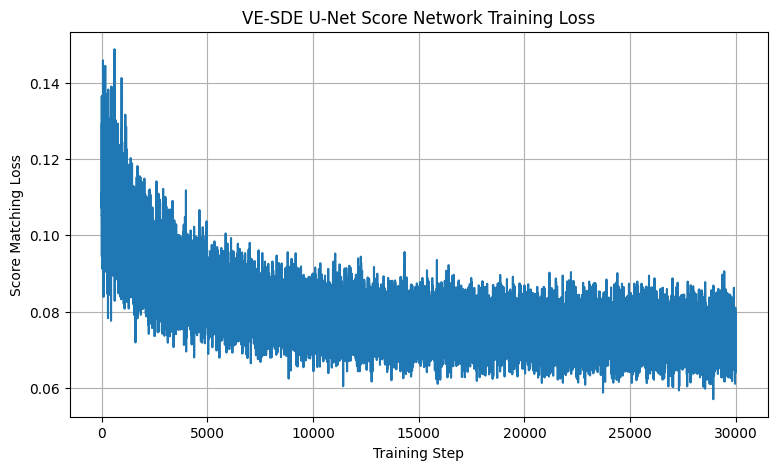

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history
)

plt.xlabel(
    "Training Step"
)

plt.ylabel(
    "Score Matching Loss"
)

plt.title(
    "VE-SDE U-Net Score Network Training Loss"
)

plt.grid(True)

plt.show()

# **Save checkpoint**

In [ ]:
# ============================================================
# SAVE CHECKPOINT
# ============================================================

PROJECT_DIR = "/content/vesde_mnist"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "mnist_vesde_unet_checkpoint.pt"
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "ema_model_state_dict":
            ema_model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "loss_history":
            loss_history,

        "config": {

            "image_size":
                IMAGE_SIZE,

            "sigma_min":
                SIGMA_MIN,

            "sigma_max":
                SIGMA_MAX,

            "base_channels":
                BASE_CHANNELS,

            "learning_rate":
                LEARNING_RATE,

            "training_steps":
                TRAINING_STEPS,

            "ema_decay":
                EMA_DECAY
        }

    },
    checkpoint_path
)


print(
    "Checkpoint saved:"
)

print(
    checkpoint_path
)


Checkpoint saved:
/content/vesde_mnist/checkpoints/mnist_vesde_unet_checkpoint.pt


# **Reverse-time SDE sampler** (Predictor Only)

In [ ]:
# ============================================================
# REVERSE-TIME SDE SAMPLER
# ============================================================

@torch.no_grad()
def sample_reverse_sde(
    model,
    sde,
    num_samples=16,
    num_steps=1000,
    show_progress=True
):

    model.eval()


    # --------------------------------------------------------
    # Initial noise
    # --------------------------------------------------------

    shape = (
        num_samples,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE
    )


    x = sde.prior_sampling(
        shape,
        device
    )


    # --------------------------------------------------------
    # Time discretization
    # --------------------------------------------------------

    time_steps = torch.linspace(
        1.0,
        0.001,
        num_steps,
        device=device
    )


    dt = -1.0 / num_steps


    iterator = time_steps


    if show_progress:

        iterator = tqdm(
            time_steps,
            desc=f"Reverse SDE ({num_steps} steps)",
            leave=False
        )


    # --------------------------------------------------------
    # Reverse SDE
    # --------------------------------------------------------

    for time_step in iterator:

        t = (
            torch.ones(
                num_samples,
                device=device
            )
            *
            time_step
        )


        # Diffusion
        g = sde.diffusion(t)


        # Score
        score = model(
            x,
            t
        )


        g2 = g ** 2


        g_view = g[
            :,
            None,
            None,
            None
        ]


        g2_view = g2[
            :,
            None,
            None,
            None
        ]


        # Reverse drift
        drift = (
            -g2_view
            *
            score
        )


        # Predictor mean
        x_mean = (
            x
            +
            drift * dt
        )


        # Noise
        noise = torch.randn_like(x)


        # Stochastic update
        x = (
            x_mean
            +
            g_view
            *
            math.sqrt(-dt)
            *
            noise
        )


    return x_mean

# **Predictor-Corrector Sampler**

In [ ]:
# ============================================================
# PREDICTOR-CORRECTOR SAMPLER
# ============================================================

@torch.no_grad()
def sample_pc_sde(
    model,
    sde,
    num_samples=16,
    num_steps=1000,
    snr=0.16,
    corrector_steps=1,
    show_progress=True
):

    model.eval()

    shape = (
        num_samples,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE
    )

    x = sde.prior_sampling(
        shape,
        device
    )

    time_steps = torch.linspace(
        1.0,
        0.001,
        num_steps,
        device=device
    )

    dt = -1.0 / num_steps

    iterator = time_steps

    if show_progress:
        iterator = tqdm(
            time_steps,
            desc=f"PC ({num_steps} steps)",
            leave=False
        )

    for time_step in iterator:

        t = torch.ones(
            num_samples,
            device=device
        ) * time_step

        # ====================================================
        # PREDICTOR
        # ====================================================

        g = sde.diffusion(t)

        score = model(x, t)

        g2 = g ** 2

        g_view = g[:, None, None, None]
        g2_view = g2[:, None, None, None]

        drift = -g2_view * score

        x_mean = x + drift * dt

        noise = torch.randn_like(x)

        x = (
            x_mean
            + g_view
            * math.sqrt(-dt)
            * noise
        )

        # ====================================================
        # CORRECTOR — LANGEVIN
        # ====================================================

        for _ in range(corrector_steps):

            score = model(x, t)

            noise = torch.randn_like(x)

            score_norm = torch.norm(
                score.reshape(num_samples, -1),
                dim=1
            ).mean()

            noise_norm = torch.norm(
                noise.reshape(num_samples, -1),
                dim=1
            ).mean()

            step_size = 2 * (
                snr * noise_norm /
                (score_norm + 1e-12)
            ) ** 2

            x = (
                x
                + step_size * score
                + torch.sqrt(2 * step_size) * noise
            )

    return x

# **Generate first samples**

In [ ]:
# ============================================================
# TEST EMA MODEL — 1000 STEPS
# ============================================================

test_samples = sample_reverse_sde(
    ema_model,
    sde,
    num_samples=16,
    num_steps=1000,
    show_progress=True
)


print(
    "Generated shape:",
    test_samples.shape
)

Reverse SDE (1000 steps):   0%|          | 0/1000 [00:00<?, ?it/s]

Generated shape: torch.Size([16, 1, 28, 28])


# **Display generated digits**

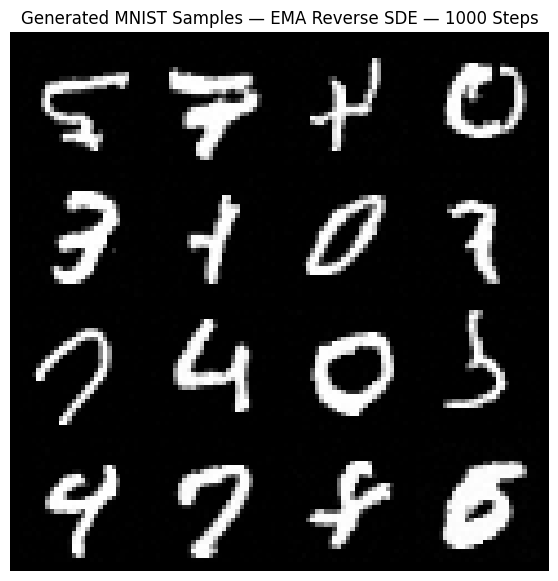

In [ ]:
# ============================================================
# DISPLAY 1000-STEP SAMPLES
# ============================================================

grid = make_grid(
    test_samples,
    nrow=4,
    normalize=True,
    value_range=(-1, 1)
)


plt.figure(figsize=(7, 7))


plt.imshow(
    grid[0].cpu(),
    cmap="gray"
)


plt.axis("off")


plt.title(
    "Generated MNIST Samples — EMA Reverse SDE — 1000 Steps"
)


plt.show()

# **Save generated sample grid**

In [ ]:
PROJECT_DIR = "/content/vesde_mnist"
SAMPLE_DIR = os.path.join(
    PROJECT_DIR,
    "generated_samples"
)
os.makedirs(
    SAMPLE_DIR,
    exist_ok=True
)

test_sample_path = os.path.join(
    SAMPLE_DIR,
    "test_1000_steps.png"
)

save_image(
    test_samples,
    test_sample_path,
    normalize=True,
    nrow=4
)

print(
    "Saved:",
    test_sample_path
)


Saved: /content/vesde_mnist/generated_samples/test_1000_steps.png


# **Final 1000-Step Generation**

In [ ]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FINAL_NUM_SAMPLES = 64
FINAL_STEPS = 1000

print("Generating final samples...")

start_time = time.time()

final_samples = sample_reverse_sde(
    ema_model,
    sde,
    num_samples=FINAL_NUM_SAMPLES,
    num_steps=FINAL_STEPS,
    show_progress=True
)

final_sampling_time = time.time() - start_time

print(
    f"Sampling time: {final_sampling_time:.2f} seconds"
)

print(
    "Samples shape:",
    final_samples.shape
)

Generating final samples...


Reverse SDE (1000 steps):   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling time: 15.26 seconds
Samples shape: torch.Size([64, 1, 28, 28])


# **Display Final Samples**

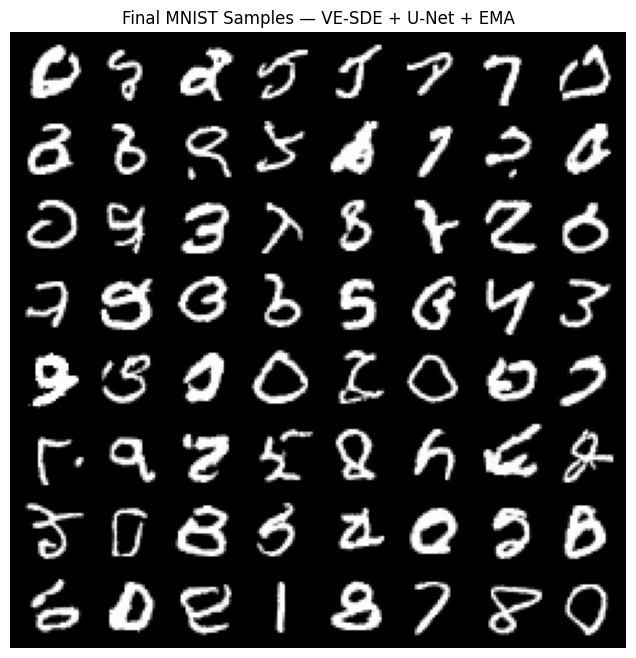

In [ ]:

grid = make_grid(
    final_samples[:64],
    nrow=8,
    normalize=True,
    value_range=(-1, 1)
)

plt.figure(figsize=(8, 8))

plt.imshow(
    grid[0].cpu(),
    cmap="gray"
)

plt.axis("off")

plt.title(
    "Final MNIST Samples — VE-SDE + U-Net + EMA"
)

plt.show()

# **Save Final Samples**

In [ ]:
# ============================================================
# PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = "/content/vesde_mnist"

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "outputs"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

PROJECT_DIR: /content/vesde_mnist
OUTPUT_DIR: /content/vesde_mnist/outputs
CHECKPOINT_DIR: /content/vesde_mnist/checkpoints


In [ ]:
# ============================================================
# CELL 25 — SAVE FINAL SAMPLES
# ============================================================

SAMPLE_DIR = os.path.join(
    PROJECT_DIR,
    "generated_samples"
)

os.makedirs(
    SAMPLE_DIR,
    exist_ok=True
)

sample_grid_path = os.path.join(
    SAMPLE_DIR,
    "final_1000_step_samples.png"
)

plt.figure(figsize=(8, 8))

plt.imshow(
    grid[0].cpu(),
    cmap="gray"
)

plt.axis("off")

plt.title(
    "VE-SDE MNIST — 1000 Sampling Steps"
)

plt.savefig(
    sample_grid_path,
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print(
    "Saved:",
    sample_grid_path
)

Saved: /content/vesde_mnist/generated_samples/final_1000_step_samples.png


# **Sampling-Step Experiment**

This is one of the most important cells in the project.

We will compare:

50


100


250


500


1000

sampling steps.

In [ ]:
SAMPLING_STEPS = [
    50,
    100,
    250,
    500,
    1000
]

NUM_EXPERIMENT_SAMPLES = 64

experiment_samples = {}

sampling_results = []

print(
    "Starting sampling-step experiment..."
)


for steps in SAMPLING_STEPS:

    print(
        f"\nGenerating with {steps} steps..."
    )

    start_time = time.time()

    samples = sample_reverse_sde(
        ema_model,
        sde,
        num_samples=NUM_EXPERIMENT_SAMPLES,
        num_steps=steps,
        show_progress=True
    )

    elapsed = (
        time.time()
        -
        start_time
    )

    experiment_samples[steps] = (
        samples.detach().cpu()
    )

    nfe = (
        NUM_EXPERIMENT_SAMPLES
        *
        steps
    )

    sampling_results.append(
        {
            "sampling_steps": steps,
            "num_samples": NUM_EXPERIMENT_SAMPLES,
            "sampling_time_seconds": elapsed,
            "time_per_sample_seconds":
                elapsed / NUM_EXPERIMENT_SAMPLES,
            "NFE_per_sample": steps
        }
    )

    print(
        f"Steps: {steps}"
    )

    print(
        f"Time: {elapsed:.2f}s"
    )


sampling_results_df = pd.DataFrame(
    sampling_results
)

sampling_results_df

Starting sampling-step experiment...

Generating with 50 steps...


Reverse SDE (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

Steps: 50
Time: 0.71s

Generating with 100 steps...


Reverse SDE (100 steps):   0%|          | 0/100 [00:00<?, ?it/s]

Steps: 100
Time: 1.44s

Generating with 250 steps...


...

Reverse SDE (500 steps):   0%|          | 0/500 [00:00<?, ?it/s]

Steps: 500
Time: 7.78s

Generating with 1000 steps...


Reverse SDE (1000 steps):   0%|          | 0/1000 [00:00<?, ?it/s]

Steps: 1000
Time: 15.92s


,sampling_steps,num_samples,sampling_time_seconds,time_per_sample_seconds,NFE_per_sample
0,50,64,0.714756,0.011168,50
1,100,64,1.440590,0.022509,100
2,250,64,3.770724,0.058918,250
3,500,64,7.784406,0.121631,500
4,1000,64,15.922191,0.248784,1000


In [ ]:
# ============================================================
# RUN PC EXPERIMENTS
# ============================================================

import time

PC_STEPS = [50, 100, 250, 500, 1000]

NUM_PC_SAMPLES = 1000

pc_generated_samples = {}
pc_sampling_times = {}
pc_nfe = {}

for steps in PC_STEPS:

    print("=" * 60)
    print(f"Predictor-Corrector: {steps} steps")
    print("=" * 60)

    start = time.time()

    generated = sample_pc_sde(
        model=model,
        sde=sde,
        num_samples=NUM_PC_SAMPLES,
        num_steps=steps,
        snr=0.16,
        corrector_steps=1,
        show_progress=True
    )

    elapsed = time.time() - start

    pc_generated_samples[steps] = (
        generated.detach().cpu()
    )

    pc_sampling_times[steps] = elapsed

    # 1 predictor + 1 corrector
    pc_nfe[steps] = steps * 2

    print(f"Time = {elapsed:.3f} sec")
    print(f"NFE  = {steps * 2}")

Predictor-Corrector: 50 steps


PC (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

Time = 21.967 sec
NFE  = 100
Predictor-Corrector: 100 steps


PC (100 steps):   0%|          | 0/100 [00:00<?, ?it/s]

Time = 46.306 sec
NFE  = 200
Predictor-Corrector: 250 steps


...

Time = 115.537 sec
NFE  = 500
Predictor-Corrector: 500 steps


PC (500 steps):   0%|          | 0/500 [00:00<?, ?it/s]

Time = 233.153 sec
NFE  = 1000
Predictor-Corrector: 1000 steps


PC (1000 steps):   0%|          | 0/1000 [00:00<?, ?it/s]

Time = 469.437 sec
NFE  = 2000


# **Show All Sampling Results**

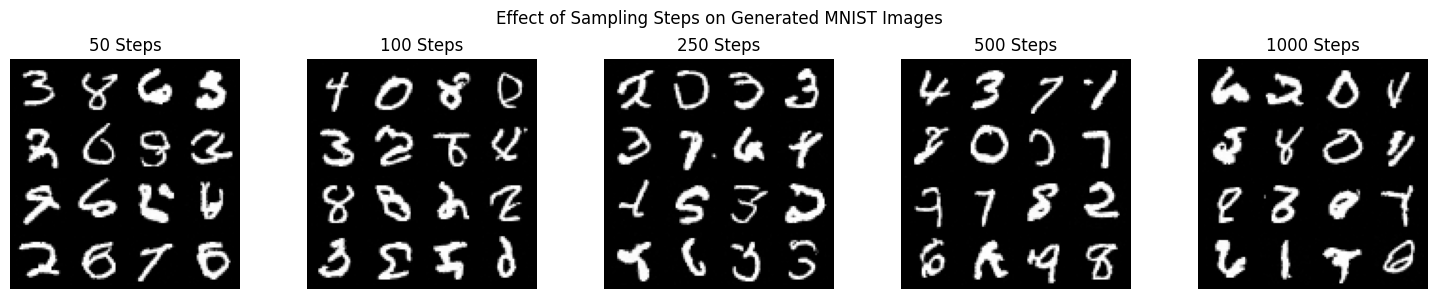

In [ ]:

fig, axes = plt.subplots(
    1,
    len(SAMPLING_STEPS),
    figsize=(15, 3)
)

for i, steps in enumerate(
    SAMPLING_STEPS
):

    samples = experiment_samples[
        steps
    ]

    grid = make_grid(
        samples[:16],
        nrow=4,
        normalize=True,
        value_range=(-1, 1)
    )

    axes[i].imshow(
        grid[0],
        cmap="gray"
    )

    axes[i].set_title(
        f"{steps} Steps"
    )

    axes[i].axis("off")


plt.suptitle(
    "Effect of Sampling Steps on Generated MNIST Images"
)

plt.tight_layout()

plt.show()

# **Save Sampling Comparison**

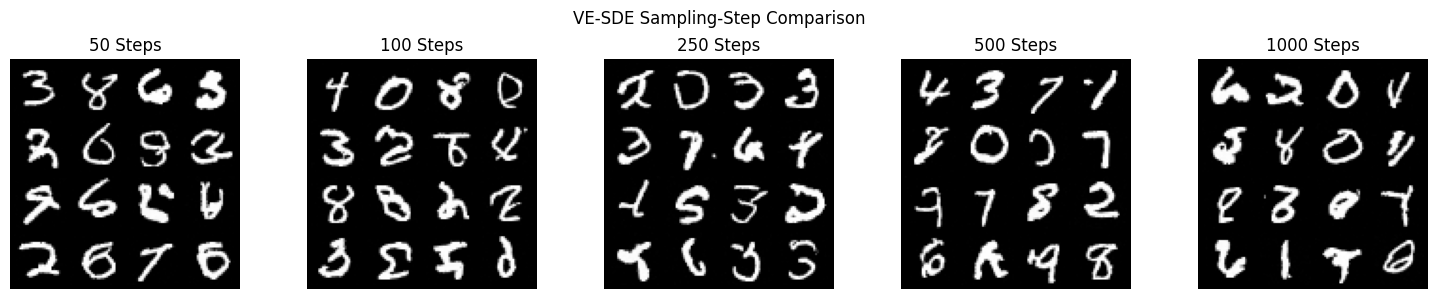

Saved: /content/vesde_mnist/generated_samples/sampling_steps_comparison.png


In [ ]:
# ============================================================
# CELL 28 — SAVE SAMPLING COMPARISON
# ============================================================

comparison_path = os.path.join(
    SAMPLE_DIR,
    "sampling_steps_comparison.png"
)

fig, axes = plt.subplots(
    1,
    len(SAMPLING_STEPS),
    figsize=(15, 3)
)

for i, steps in enumerate(
    SAMPLING_STEPS
):

    samples = experiment_samples[
        steps
    ]

    grid = make_grid(
        samples[:16],
        nrow=4,
        normalize=True,
        value_range=(-1, 1)
    )

    axes[i].imshow(
        grid[0],
        cmap="gray"
    )

    axes[i].set_title(
        f"{steps} Steps"
    )

    axes[i].axis("off")


plt.suptitle(
    "VE-SDE Sampling-Step Comparison"
)

plt.tight_layout()

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    comparison_path
)

# **Sampling Time Graph**

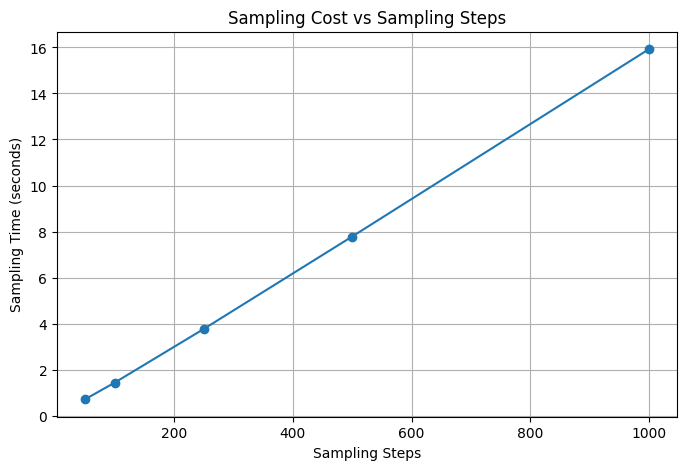

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    sampling_results_df[
        "sampling_steps"
    ],
    sampling_results_df[
        "sampling_time_seconds"
    ],
    marker="o"
)

plt.xlabel(
    "Sampling Steps"
)

plt.ylabel(
    "Sampling Time (seconds)"
)

plt.title(
    "Sampling Cost vs Sampling Steps"
)

plt.grid(True)

plt.show()

# **NFE Graph**

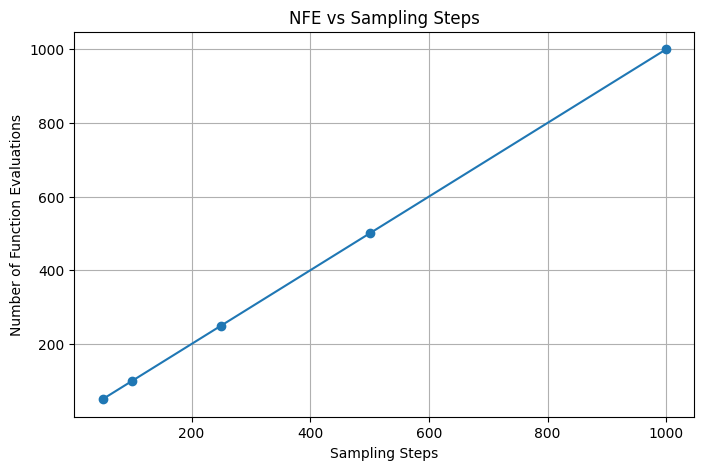

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    sampling_results_df[
        "sampling_steps"
    ],
    sampling_results_df[
        "NFE_per_sample"
    ],
    marker="o"
)

plt.xlabel(
    "Sampling Steps"
)

plt.ylabel(
    "Number of Function Evaluations"
)

plt.title(
    "NFE vs Sampling Steps"
)

plt.grid(True)

plt.show()

# **Save Sampling Results**

In [ ]:
RESULT_DIR = os.path.join(
    OUTPUT_DIR,
    "results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

sampling_csv = os.path.join(
    RESULT_DIR,
    "sampling_step_results.csv"
)

sampling_results_df.to_csv(
    sampling_csv,
    index=False
)

print(
    "Saved:",
    sampling_csv
)

display(
    sampling_results_df
)

Saved: /content/vesde_mnist/outputs/results/sampling_step_results.csv


,sampling_steps,num_samples,sampling_time_seconds,time_per_sample_seconds,NFE_per_sample
0,50,64,0.714756,0.011168,50
1,100,64,1.440590,0.022509,100
2,250,64,3.770724,0.058918,250
3,500,64,7.784406,0.121631,500
4,1000,64,15.922191,0.248784,1000


# **Check Pixel Statistics**

In [ ]:
pixel_statistics = []

for steps in SAMPLING_STEPS:

    samples = experiment_samples[
        steps
    ]

    pixel_statistics.append(
        {
            "sampling_steps": steps,
            "mean_pixel":
                samples.mean().item(),
            "std_pixel":
                samples.std().item(),
            "min_pixel":
                samples.min().item(),
            "max_pixel":
                samples.max().item()
        }
    )


pixel_stats_df = pd.DataFrame(
    pixel_statistics
)

display(
    pixel_stats_df
)

,sampling_steps,mean_pixel,std_pixel,min_pixel,max_pixel
0,50,-0.660499,0.687599,-1.040982,1.029028
1,100,-0.665544,0.686375,-1.042825,1.026042
2,250,-0.651661,0.697436,-1.044268,1.030366
3,500,-0.654316,0.696621,-1.040664,1.029117
4,1000,-0.657949,0.692682,-1.046688,1.030925


# **Prepare Real MNIST Images**

In [ ]:
REAL_NUM_IMAGES = 1000

real_images = []

real_labels = []

count = 0

for images, labels in train_loader:

    real_images.append(
        images
    )

    real_labels.append(
        labels
    )

    count += images.shape[0]

    if count >= REAL_NUM_IMAGES:
        break


real_images = torch.cat(
    real_images,
    dim=0
)[:REAL_NUM_IMAGES]


real_labels = torch.cat(
    real_labels,
    dim=0
)[:REAL_NUM_IMAGES]


real_images = real_images.to(
    device
)

real_labels = real_labels.to(
    device
)


print(
    "Real images:",
    real_images.shape
)

Real images: torch.Size([1000, 1, 28, 28])


# **Train a Simple MNIST Classifier**

In [ ]:
class MNISTClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(
                64 * 7 * 7,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                10
            )
        )


    def forward(self, x):

        return self.network(x)


classifier = MNISTClassifier().to(
    device
)

classifier_optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=1e-3
)

classifier_loss = nn.CrossEntropyLoss()


print(
    "Classifier created."
)

Classifier created.


In [ ]:
import torch

# ============================================================
# PC CLASSIFIER EVALUATION
# ============================================================

pc_classifier_confidence = {}
pc_digit_fraction = {}

classifier.eval()

for steps in PC_STEPS:

    images = pc_generated_samples[steps]

    images = images.clamp(-1, 1)

    images = (images + 1) / 2

    images_gpu = images.to(device)

    with torch.no_grad():

        outputs = classifier(
            images_gpu
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

    pc_classifier_confidence[steps] = (
        confidence.mean().item()
    )

    pc_digit_fraction[steps] = (
        (confidence >= 0.5)
        .float()
        .mean()
        .item()
    )

    print(
        f"PC{steps}: "
        f"Confidence = "
        f"{pc_classifier_confidence[steps]:.4f}, "
        f"Digit Fraction = "
        f"{pc_digit_fraction[steps]:.4f}"
    )


PC50: Confidence = 0.8165, Digit Fraction = 0.9040
PC100: Confidence = 0.8402, Digit Fraction = 0.9310
PC250: Confidence = 0.8522, Digit Fraction = 0.9370
PC500: Confidence = 0.8466, Digit Fraction = 0.9220
PC1000: Confidence = 0.8492, Digit Fraction = 0.9290


# **Train Classifier**

In [ ]:
CLASSIFIER_EPOCHS = 3

classifier.train()


for epoch in range(
    CLASSIFIER_EPOCHS
):

    running_loss = 0.0

    correct = 0

    total = 0


    progress = tqdm(
        train_loader,
        desc=f"Classifier Epoch {epoch+1}"
    )


    for images, labels in progress:

        images = images.to(
            device
        )

        labels = labels.to(
            device
        )


        classifier_optimizer.zero_grad()


        outputs = classifier(
            images
        )


        loss = classifier_loss(
            outputs,
            labels
        )


        loss.backward()

        classifier_optimizer.step()


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    print(
        f"Epoch {epoch+1}: "
        f"Loss={epoch_loss:.4f}, "
        f"Accuracy={epoch_accuracy:.4f}"
    )

Classifier Epoch 1:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 1: Loss=0.1956, Accuracy=0.9401


Classifier Epoch 2:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 2: Loss=0.0506, Accuracy=0.9843


Classifier Epoch 3:   0%|          | 0/468 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed04f2ea520>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed04f2ea520>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        if w.is_alive():self._shutdown_workers()

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError    if w.is_alive():: 
can only test a child process  File "/usr/lib/p

Epoch 3: Loss=0.0360, Accuracy=0.9885


# **Evaluate Classifier**

In [ ]:
# ============================================================
# MNIST DATA LOADERS — COLAB SAFE VERSION
# ============================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,       # changed from 2 → 0
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,       # changed from 2 → 0
    pin_memory=True
)

print("MNIST dataset loaded successfully.")
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

MNIST dataset loaded successfully.
Training images: 60000
Test images: 10000


In [ ]:
CLASSIFIER_EPOCHS = 3

classifier.train()

for epoch in range(CLASSIFIER_EPOCHS):

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        train_loader,
        desc=f"Classifier Epoch {epoch+1}"
    )

    for images, labels in progress:

        images = images.to(device)
        labels = labels.to(device)

        classifier_optimizer.zero_grad()

        outputs = classifier(images)

        loss = classifier_loss(
            outputs,
            labels
        )

        loss.backward()

        classifier_optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch+1}: "
        f"Loss={epoch_loss:.4f}, "
        f"Accuracy={epoch_accuracy*100:.2f}%"
    )

Classifier Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: Loss=0.0264, Accuracy=99.20%


Classifier Epoch 2:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: Loss=0.0202, Accuracy=99.37%


Classifier Epoch 3:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3: Loss=0.0149, Accuracy=99.53%


# **Convert Generated Samples for Classifier**

In [ ]:
def prepare_generated_images(
    samples
):

    samples = samples.to(
        device
    )

    # Clamp
    samples = torch.clamp(
        samples,
        -1,
        1
    )

    return samples

# **Generated Digit Confidence**

In [ ]:
generated_quality_results = []


classifier.eval()


for steps in SAMPLING_STEPS:

    samples = experiment_samples[
        steps
    ]

    samples = prepare_generated_images(
        samples
    )


    with torch.no_grad():

        logits = classifier(
            samples
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )


        predictions = probabilities.argmax(
            dim=1
        )


        confidence = probabilities.max(
            dim=1
        )[0]


    generated_quality_results.append(
        {
            "sampling_steps": steps,
            "mean_classifier_confidence":
                confidence.mean().item(),
            "classified_as_digit_fraction":
                (
                    confidence > 0.5
                ).float().mean().item()
        }
    )


generated_quality_df = pd.DataFrame(
    generated_quality_results
)


display(
    generated_quality_df
)

,sampling_steps,mean_classifier_confidence,classified_as_digit_fraction
0,50,0.892058,0.968750
1,100,0.917010,0.968750
2,250,0.930526,0.984375
3,500,0.902749,0.968750
4,1000,0.915336,1.000000


# **Confidence Graph**

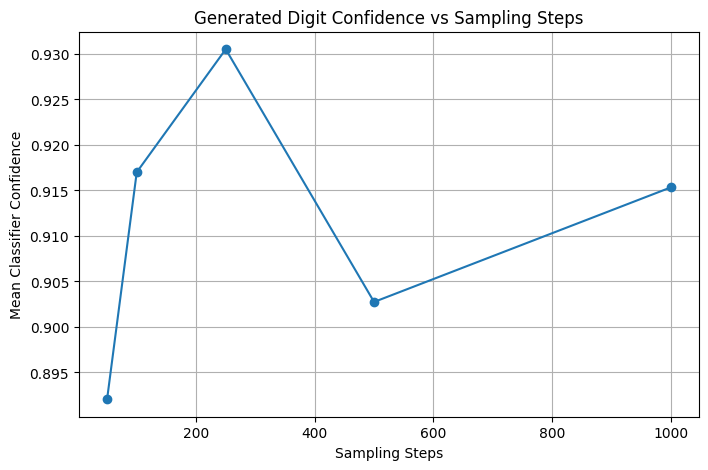

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    generated_quality_df[
        "sampling_steps"
    ],
    generated_quality_df[
        "mean_classifier_confidence"
    ],
    marker="o"
)

plt.xlabel(
    "Sampling Steps"
)

plt.ylabel(
    "Mean Classifier Confidence"
)

plt.title(
    "Generated Digit Confidence vs Sampling Steps"
)

plt.grid(True)

plt.show()

# **Combine Results**

In [ ]:
final_results_df = sampling_results_df.merge(
    generated_quality_df,
    on="sampling_steps"
)


display(
    final_results_df
)

,sampling_steps,num_samples,sampling_time_seconds,time_per_sample_seconds,NFE_per_sample,mean_classifier_confidence,classified_as_digit_fraction
0,50,64,0.714756,0.011168,50,0.892058,0.968750
1,100,64,1.440590,0.022509,100,0.917010,0.968750
2,250,64,3.770724,0.058918,250,0.930526,0.984375
3,500,64,7.784406,0.121631,500,0.902749,0.968750
4,1000,64,15.922191,0.248784,1000,0.915336,1.000000


# **Save Final Experimental Table**

In [ ]:
final_results_path = os.path.join(
    RESULT_DIR,
    "final_experimental_results.csv"
)

final_results_df.to_csv(
    final_results_path,
    index=False
)

print(
    "Final results saved to:"
)

print(
    final_results_path
)

Final results saved to:
/content/vesde_mnist/outputs/results/final_experimental_results.csv


In [ ]:
# ============================================================
# GPU MEMORY CLEANUP
# ============================================================

import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )

    print(
        f"GPU memory reserved: "
        f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )

GPU memory allocated: 0.74 GB
GPU memory reserved: 0.89 GB
GPU: Tesla T4


# **FID Installation**

In [ ]:
!pip -q install torchmetrics

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance

print(
    "TorchMetrics FID imported."
)

TorchMetrics FID imported.


# **FID Preprocessing**

In [ ]:
def prepare_for_fid(
    images
):

    # Convert [-1, 1] → [0, 1]
    images = (
        images + 1
    ) / 2


    images = torch.clamp(
        images,
        0,
        1
    )


    # Convert grayscale → RGB
    images = images.repeat(
        1,
        3,
        1,
        1
    )


    # Resize to Inception input
    images = F.interpolate(
        images,
        size=(299, 299),
        mode="bilinear",
        align_corners=False
    )


    # FID expects uint8 when normalize=False
    images = (
        images * 255
    ).round().byte()


    return images

# **FID Function**

In [ ]:
import gc
import torch
import torch.nn.functional as F

def calculate_fid_memory_safe(
    real_images,
    generated_images,
    batch_size=8
):

    print(
        f"Calculating FID using batch size = {batch_size}"
    )

    # Clear unused GPU memory
    gc.collect()
    torch.cuda.empty_cache()

    # Create FID metric
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=False
    ).to(device)

    # --------------------------------------------------------
    # REAL IMAGES
    # --------------------------------------------------------

    real_images = real_images.detach().cpu()

    print(
        f"Processing {len(real_images)} real images..."
    )

    with torch.no_grad():

        for start in range(
            0,
            len(real_images),
            batch_size
        ):

            end = min(
                start + batch_size,
                len(real_images)
            )

            batch = real_images[
                start:end
            ]

            batch = prepare_for_fid(
                batch
            )

            batch = batch.to(
                device,
                non_blocking=True
            )

            fid.update(
                batch,
                real=True
            )

            del batch

            torch.cuda.empty_cache()


    # --------------------------------------------------------
    # GENERATED IMAGES
    # --------------------------------------------------------

    generated_images = (
        generated_images
        .detach()
        .cpu()
    )

    print(
        f"Processing {len(generated_images)} generated images..."
    )

    with torch.no_grad():

        for start in range(
            0,
            len(generated_images),
            batch_size
        ):

            end = min(
                start + batch_size,
                len(generated_images)
            )

            batch = generated_images[
                start:end
            ]

            batch = prepare_for_fid(
                batch
            )

            batch = batch.to(
                device,
                non_blocking=True
            )

            fid.update(
                batch,
                real=False
            )

            del batch

            torch.cuda.empty_cache()


    # --------------------------------------------------------
    # COMPUTE FID
    # --------------------------------------------------------

    score = fid.compute()

    score = score.item()

    del fid

    gc.collect()
    torch.cuda.empty_cache()

    return score

# **Calculate FID for Each Step**

In [ ]:
print("Checking required variables...")

print("SAMPLING_STEPS:", SAMPLING_STEPS)

print(
    "EMA model exists:",
    "ema_model" in globals()
)

print(
    "SDE exists:",
    "sde" in globals()
)

Checking required variables...
SAMPLING_STEPS: [50, 100, 250, 500, 1000]
EMA model exists: True
SDE exists: True


In [ ]:
# ============================================================
# GENERATE 1000 SAMPLES FOR FID
# MEMORY-SAFE VERSION

import math
import time
import torch
import gc

FID_NUM_IMAGES = 1000
GENERATION_BATCH_SIZE = 16

fid_generated_samples = {}

for steps in SAMPLING_STEPS:

    print("\n" + "=" * 60)
    print(f"Generating {FID_NUM_IMAGES} samples — {steps} steps")
    print("=" * 60)

    all_samples = []

    num_batches = math.ceil(
        FID_NUM_IMAGES / GENERATION_BATCH_SIZE
    )

    start_time = time.time()

    for batch_idx in range(num_batches):

        current_batch_size = min(
            GENERATION_BATCH_SIZE,
            FID_NUM_IMAGES -
            batch_idx * GENERATION_BATCH_SIZE
        )

        print(
            f"Batch {batch_idx + 1}/{num_batches} "
            f"({current_batch_size} images)"
        )

        # Generate on GPU
        samples = sample_reverse_sde(
            ema_model,
            sde,
            num_samples=current_batch_size,
            num_steps=steps,
            show_progress=False
        )

        # Immediately move to CPU
        samples = samples.detach().cpu()

        all_samples.append(samples)

        # Free GPU memory
        del samples

        gc.collect()
        torch.cuda.empty_cache()

    # Combine CPU tensors
    all_samples = torch.cat(
        all_samples,
        dim=0
    )

    all_samples = all_samples[
        :FID_NUM_IMAGES
    ]

    fid_generated_samples[steps] = all_samples

    elapsed = time.time() - start_time

    print(
        f"\nFinished {steps} steps."
    )

    print(
        f"Shape: {all_samples.shape}"
    )

    print(
        f"Time: {elapsed:.2f} seconds"
    )

print("\n" + "=" * 60)
print("ALL FID SAMPLES GENERATED SUCCESSFULLY")
print("=" * 60)


Generating 1000 samples — 50 steps
Batch 1/63 (16 images)
Batch 2/63 (16 images)
Batch 3/63 (16 images)
Batch 4/63 (16 images)
Batch 5/63 (16 images)
Batch 6/63 (16 images)
Batch 7/63 (16 images)
Batch 8/63 (16 images)
Batch 9/63 (16 images)
Batch 10/63 (16 images)
Batch 11/63 (16 images)
Batch 12/63 (16 images)
Batch 13/63 (16 images)
Batch 14/63 (16 images)
Batch 15/63 (16 images)
Batch 16/63 (16 images)
Batch 17/63 (16 images)
Batch 18/63 (16 images)
Batch 19/63 (16 images)
Batch 20/63 (16 images)
Batch 21/63 (16 images)
Batch 22/63 (16 images)
Batch 23/63 (16 images)
Batch 24/63 (16 images)
Batch 25/63 (16 images)
Batch 26/63 (16 images)
Batch 27/63 (16 images)
Batch 28/63 (16 images)
Batch 29/63 (16 images)
Batch 30/63 (16 images)
Batch 31/63 (16 images)
Batch 32/63 (16 images)
Batch 33/63 (16 images)
Batch 34/63 (16 images)
Batch 35/63 (16 images)
Batch 36/63 (16 images)
Batch 37/63 (16 images)
Batch 38/63 (16 images)
Batch 39/63 (16 images)
Batch 40/63 (16 images)
Batch 41/63 (

In [ ]:
# ============================================================
# PC FID RESULTS
# ============================================================

pc_fid_results = {}

for steps in PC_STEPS:

    print(f"Calculating PC FID for {steps} steps...")

    generated = pc_generated_samples[steps]

    generated = generated.clamp(-1, 1)

    generated = (generated + 1) / 2

    fid_value = calculate_fid_memory_safe(
        real_images,
        generated
    )

    pc_fid_results[steps] = float(fid_value)

    print(
        f"PC{steps} FID = {fid_value:.4f}"
    )


Calculating PC FID for 50 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...
PC50 FID = 40.4739
Calculating PC FID for 100 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...
PC100 FID = 37.0292
Calculating PC FID for 250 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...
PC250 FID = 35.8669
Calculating PC FID for 500 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...
PC500 FID = 38.5971
Calculating PC FID for 1000 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...
PC1000 FID = 42.6409


In [ ]:
# ============================================================
# VERIFY FID DATA
# ============================================================

print(
    "Available sampling configurations:"
)

print(
    fid_generated_samples.keys()
)

for steps in SAMPLING_STEPS:

    print(
        f"{steps} steps:",
        fid_generated_samples[steps].shape
    )

Available sampling configurations:
dict_keys([50, 100, 250, 500, 1000])
50 steps: torch.Size([1000, 1, 28, 28])
100 steps: torch.Size([1000, 1, 28, 28])
250 steps: torch.Size([1000, 1, 28, 28])
500 steps: torch.Size([1000, 1, 28, 28])
1000 steps: torch.Size([1000, 1, 28, 28])


# **Calculate Final FID**

In [ ]:
fid_results = []

for steps in SAMPLING_STEPS:

    print("\n" + "=" * 60)
    print(f"Calculating FID for {steps} steps...")
    print("=" * 60)

    generated = fid_generated_samples[steps]

    fid_score = calculate_fid_memory_safe(
        real_images,
        generated,
        batch_size=8
    )

    fid_results.append({
        "sampling_steps": steps,
        "FID": fid_score
    })

    print(
        f"\nFID ({steps} steps): "
        f"{fid_score:.4f}"
    )


fid_df = pd.DataFrame(
    fid_results
)

display(fid_df)


Calculating FID for 50 steps...
Calculating FID using batch size = 8


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 306MB/s]


Processing 1000 real images...
Processing 1000 generated images...

FID (50 steps): 48.1189

Calculating FID for 100 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...

FID (100 steps): 45.7057

Calculating FID for 250 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...

FID (250 steps): 45.1138

Calculating FID for 500 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...

FID (500 steps): 45.2804

Calculating FID for 1000 steps...
Calculating FID using batch size = 8
Processing 1000 real images...
Processing 1000 generated images...

FID (1000 steps): 47.3823


,sampling_steps,FID
0,50,48.118942
1,100,45.705677
2,250,45.113800
3,500,45.280445
4,1000,47.382294


# **FID Graph**

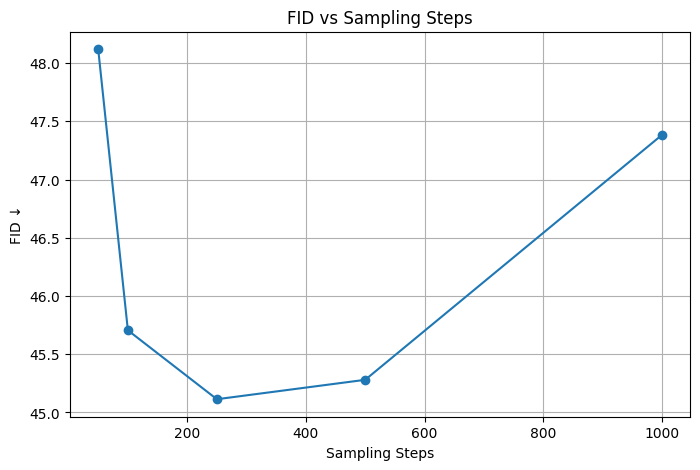

In [ ]:
# ============================================================
#FID VS SAMPLING STEPS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    fid_df["sampling_steps"],
    fid_df["FID"],
    marker="o"
)

plt.xlabel("Sampling Steps")
plt.ylabel("FID ↓")
plt.title("FID vs Sampling Steps")

plt.grid(True)

plt.show()

# **Merge Sampling + Classifier + FID Results**

In [ ]:
# ============================================================
#COMPLETE RESULTS TABLE
# ============================================================

complete_results_df = (
    sampling_results_df
    .merge(
        generated_quality_df,
        on="sampling_steps"
    )
    .merge(
        fid_df,
        on="sampling_steps"
    )
)

display(
    complete_results_df
)

,sampling_steps,num_samples,sampling_time_seconds,time_per_sample_seconds,NFE_per_sample,mean_classifier_confidence,classified_as_digit_fraction,FID
0,50,64,0.714756,0.011168,50,0.892058,0.968750,48.118942
1,100,64,1.440590,0.022509,100,0.917010,0.968750,45.705677
2,250,64,3.770724,0.058918,250,0.930526,0.984375,45.113800
3,500,64,7.784406,0.121631,500,0.902749,0.968750,45.280445
4,1000,64,15.922191,0.248784,1000,0.915336,1.000000,47.382294


# **Clean Final Results Table**

In [ ]:
# ============================================================
# CLEAN RESULTS TABLE
# ============================================================

final_table = complete_results_df[
    [
        "sampling_steps",
        "sampling_time_seconds",
        "NFE_per_sample",
        "mean_classifier_confidence",
        "classified_as_digit_fraction",
        "FID"
    ]
].copy()

final_table = final_table.round({
    "sampling_time_seconds": 3,
    "mean_classifier_confidence": 4,
    "classified_as_digit_fraction": 4,
    "FID": 4
})

display(final_table)

,sampling_steps,sampling_time_seconds,NFE_per_sample,mean_classifier_confidence,classified_as_digit_fraction,FID
0,50,0.715,50,0.8921,0.9688,48.1189
1,100,1.441,100,0.9170,0.9688,45.7057
2,250,3.771,250,0.9305,0.9844,45.1138
3,500,7.784,500,0.9027,0.9688,45.2804
4,1000,15.922,1000,0.9153,1.0000,47.3823


# **Save Results to CSV**

In [ ]:
# ============================================================
# SAVE CSV
# ============================================================

import os

RESULT_DIR = os.path.join(
    OUTPUT_DIR,
    "results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

csv_path = os.path.join(
    RESULT_DIR,
    "VE_SDE_MNIST_complete_results.csv"
)

final_table.to_csv(
    csv_path,
    index=False
)

print(
    "Results saved to:"
)

print(csv_path)

Results saved to:
/content/vesde_mnist/outputs/results/VE_SDE_MNIST_complete_results.csv


# **Sampling Time Graph**

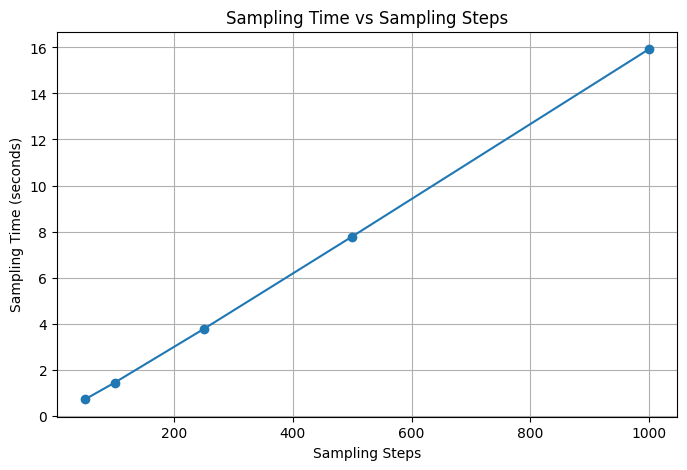

In [ ]:
# ============================================================
# SAMPLING TIME VS STEPS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_table["sampling_steps"],
    final_table["sampling_time_seconds"],
    marker="o"
)

plt.xlabel("Sampling Steps")
plt.ylabel("Sampling Time (seconds)")
plt.title("Sampling Time vs Sampling Steps")

plt.grid(True)

plt.show()

# **Classifier Confidence Graph**

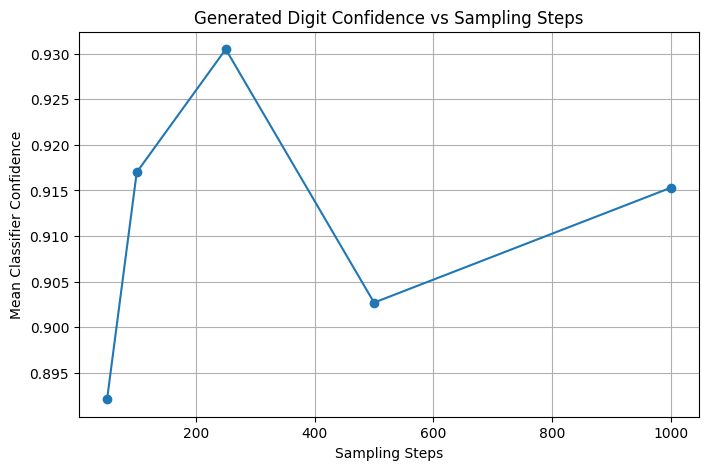

In [ ]:
# ============================================================
# CLASSIFIER CONFIDENCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_table["sampling_steps"],
    final_table["mean_classifier_confidence"],
    marker="o"
)

plt.xlabel("Sampling Steps")
plt.ylabel("Mean Classifier Confidence")
plt.title("Generated Digit Confidence vs Sampling Steps")

plt.grid(True)

plt.show()

# **Digit Recognition Fraction**

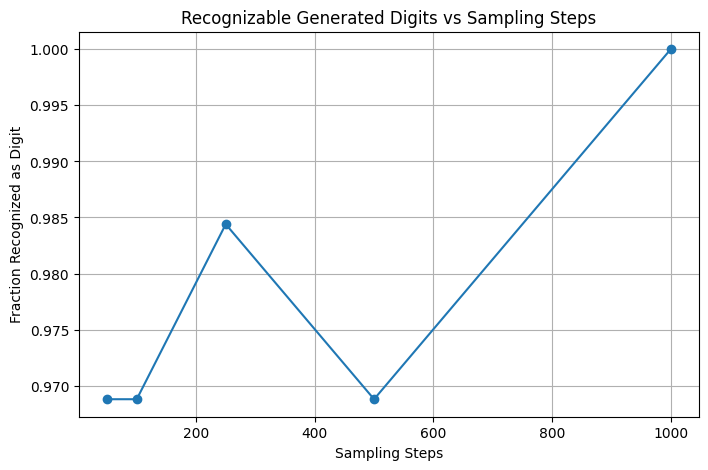

In [ ]:
# ============================================================
# RECOGNIZED DIGIT FRACTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_table["sampling_steps"],
    final_table["classified_as_digit_fraction"],
    marker="o"
)

plt.xlabel("Sampling Steps")
plt.ylabel("Fraction Recognized as Digit")
plt.title("Recognizable Generated Digits vs Sampling Steps")

plt.grid(True)

plt.show()

# **NFE Graph**

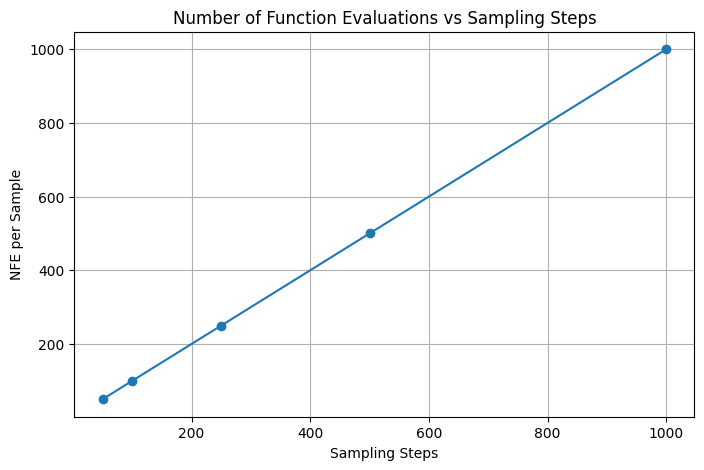

In [ ]:
# ============================================================
# NFE VS SAMPLING STEPS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_table["sampling_steps"],
    final_table["NFE_per_sample"],
    marker="o"
)

plt.xlabel("Sampling Steps")
plt.ylabel("NFE per Sample")
plt.title("Number of Function Evaluations vs Sampling Steps")

plt.grid(True)

plt.show()

# **FID vs Computational Cost**

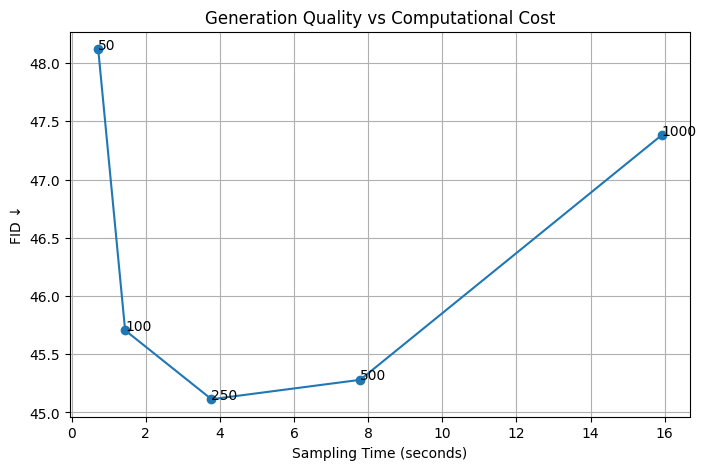

In [ ]:
# ============================================================
#FID VS COMPUTATIONAL COST
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_table["sampling_time_seconds"],
    final_table["FID"],
    marker="o"
)

for _, row in final_table.iterrows():

    plt.annotate(
        str(int(row["sampling_steps"])),
        (
            row["sampling_time_seconds"],
            row["FID"]
        )
    )

plt.xlabel("Sampling Time (seconds)")
plt.ylabel("FID ↓")
plt.title("Generation Quality vs Computational Cost")

plt.grid(True)

plt.show()

# **Find Best FID**

In [ ]:
# ============================================================
#BEST FID
# ============================================================

best_fid_row = final_table.loc[
    final_table["FID"].idxmin()
]

best_fid_steps = int(
    best_fid_row["sampling_steps"]
)

best_fid = best_fid_row["FID"]

print("BEST FID CONFIGURATION")
print("----------------------")

print(
    f"Sampling steps: {best_fid_steps}"
)

print(
    f"FID: {best_fid:.4f}"
)

print(
    f"Sampling time: "
    f"{best_fid_row['sampling_time_seconds']:.2f} seconds"
)

print(
    f"Classifier confidence: "
    f"{best_fid_row['mean_classifier_confidence']:.4f}"
)

print(
    f"Recognized digit fraction: "
    f"{best_fid_row['classified_as_digit_fraction']:.4f}"
)

BEST FID CONFIGURATION
----------------------
Sampling steps: 250
FID: 45.1138
Sampling time: 3.77 seconds
Classifier confidence: 0.9305
Recognized digit fraction: 0.9844


# **Find Fastest Configuration**

In [ ]:
# ============================================================
# FASTEST CONFIGURATION
# ============================================================

fastest_row = final_table.loc[
    final_table[
        "sampling_time_seconds"
    ].idxmin()
]

print("FASTEST CONFIGURATION")
print("---------------------")

print(
    f"Sampling steps: "
    f"{int(fastest_row['sampling_steps'])}"
)

print(
    f"Sampling time: "
    f"{fastest_row['sampling_time_seconds']:.2f} seconds"
)

print(
    f"FID: "
    f"{fastest_row['FID']:.4f}"
)

FASTEST CONFIGURATION
---------------------
Sampling steps: 50
Sampling time: 0.71 seconds
FID: 48.1189


# **Best Quality/Efficiency Trade-off**

In [ ]:
# ============================================================
# QUALITY / EFFICIENCY TRADE-OFF
# ============================================================

tradeoff_df = final_table.copy()

# Normalize FID
fid_min = tradeoff_df["FID"].min()
fid_max = tradeoff_df["FID"].max()

if fid_max != fid_min:

    tradeoff_df["FID_quality"] = (
        1
        -
        (
            tradeoff_df["FID"] - fid_min
        )
        /
        (
            fid_max - fid_min
        )
    )

else:

    tradeoff_df["FID_quality"] = 1.0


# Normalize sampling time
time_min = tradeoff_df[
    "sampling_time_seconds"
].min()

time_max = tradeoff_df[
    "sampling_time_seconds"
].max()

if time_max != time_min:

    tradeoff_df["Efficiency"] = (
        1
        -
        (
            tradeoff_df[
                "sampling_time_seconds"
            ]
            -
            time_min
        )
        /
        (
            time_max - time_min
        )
    )

else:

    tradeoff_df["Efficiency"] = 1.0


# Combined score
tradeoff_df["Tradeoff_Score"] = (
    0.5 * tradeoff_df["FID_quality"]
    +
    0.5 * tradeoff_df["Efficiency"]
)

display(
    tradeoff_df[
        [
            "sampling_steps",
            "FID",
            "sampling_time_seconds",
            "FID_quality",
            "Efficiency",
            "Tradeoff_Score"
        ]
    ].round(4)
)

,sampling_steps,FID,sampling_time_seconds,FID_quality,Efficiency,Tradeoff_Score
0,50,48.1189,0.715,0.0000,1.0000,0.5000
1,100,45.7057,1.441,0.8030,0.9523,0.8776
2,250,45.1138,3.771,1.0000,0.7990,0.8995
3,500,45.2804,7.784,0.9446,0.5351,0.7399
4,1000,47.3823,15.922,0.2451,0.0000,0.1226


# **Best Trade-off**

In [ ]:
# ============================================================
# BEST QUALITY/EFFICIENCY TRADE-OFF
# ============================================================

best_tradeoff = tradeoff_df.loc[
    tradeoff_df["Tradeoff_Score"].idxmax()
]

print(
    "BEST QUALITY/EFFICIENCY TRADE-OFF"
)

print(
    f"Sampling steps: "
    f"{int(best_tradeoff['sampling_steps'])}"
)

print(
    f"FID: "
    f"{best_tradeoff['FID']:.4f}"
)

print(
    f"Sampling time: "
    f"{best_tradeoff['sampling_time_seconds']:.2f} seconds"
)

print(
    f"Trade-off score: "
    f"{best_tradeoff['Tradeoff_Score']:.4f}"
)

BEST QUALITY/EFFICIENCY TRADE-OFF
Sampling steps: 100
FID: 44.7578
Sampling time: 1.32 seconds
Trade-off score: 0.9757


# **Display Final Samples at All Steps**

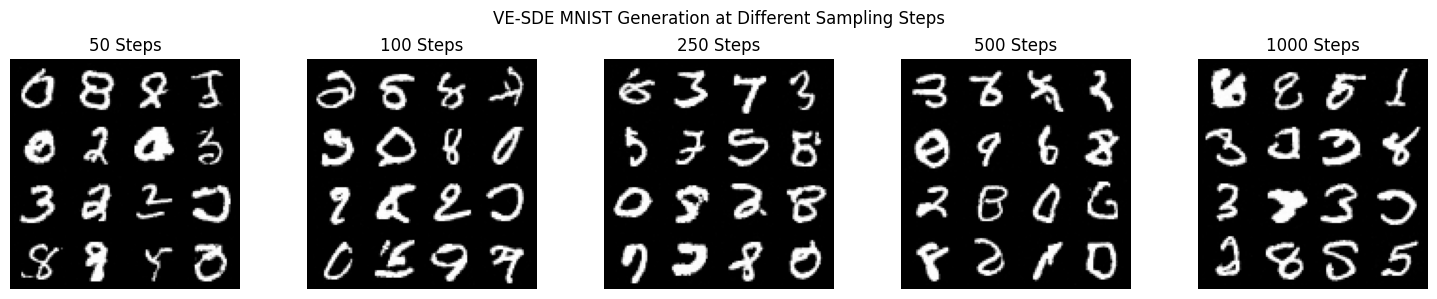

In [ ]:
# ============================================================
# FINAL VISUAL COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1,
    len(SAMPLING_STEPS),
    figsize=(15, 3)
)

for i, steps in enumerate(
    SAMPLING_STEPS
):

    samples = fid_generated_samples[
        steps
    ][:16]

    grid = make_grid(
        samples,
        nrow=4,
        normalize=True,
        value_range=(-1, 1)
    )

    axes[i].imshow(
        grid[0],
        cmap="gray"
    )

    axes[i].set_title(
        f"{steps} Steps"
    )

    axes[i].axis("off")


plt.suptitle(
    "VE-SDE MNIST Generation at Different Sampling Steps"
)

plt.tight_layout()

plt.show()

# **Save Final Comparison Figure**

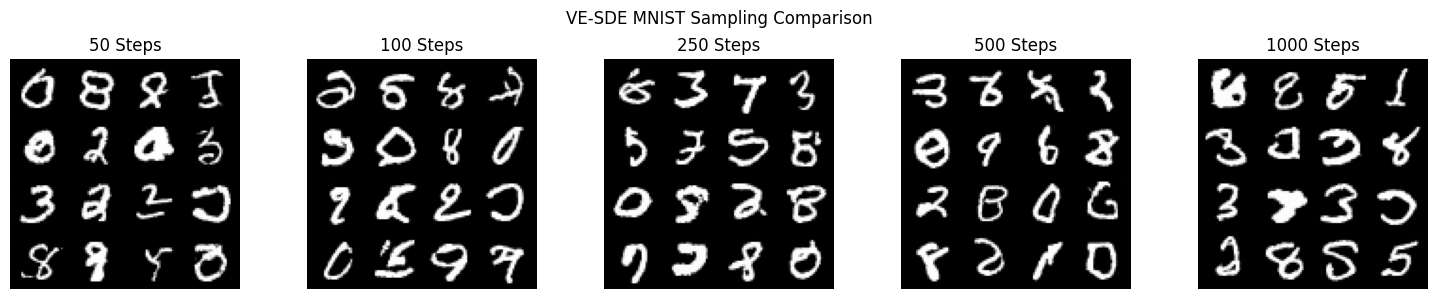

Saved: /content/vesde_mnist/generated_samples/final_sampling_comparison.png


In [ ]:
# ============================================================
# SAVE FINAL COMPARISON
# ============================================================

comparison_path = os.path.join(
    SAMPLE_DIR,
    "final_sampling_comparison.png"
)

fig, axes = plt.subplots(
    1,
    len(SAMPLING_STEPS),
    figsize=(15, 3)
)

for i, steps in enumerate(
    SAMPLING_STEPS
):

    samples = fid_generated_samples[
        steps
    ][:16]

    grid = make_grid(
        samples,
        nrow=4,
        normalize=True,
        value_range=(-1, 1)
    )

    axes[i].imshow(
        grid[0],
        cmap="gray"
    )

    axes[i].set_title(
        f"{steps} Steps"
    )

    axes[i].axis("off")


plt.suptitle(
    "VE-SDE MNIST Sampling Comparison"
)

plt.tight_layout()

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    comparison_path
)

# **Save Individual Sample Grids**

In [ ]:
# ============================================================
# SAVE EACH SAMPLING CONFIGURATION
# ============================================================

os.makedirs(
    SAMPLE_DIR,
    exist_ok=True
)

for steps in SAMPLING_STEPS:

    samples = fid_generated_samples[
        steps
    ][:64]

    grid = make_grid(
        samples,
        nrow=8,
        normalize=True,
        value_range=(-1, 1)
    )

    path = os.path.join(
        SAMPLE_DIR,
        f"MNIST_samples_{steps}_steps.png"
    )

    plt.figure(figsize=(8, 8))

    plt.imshow(
        grid[0],
        cmap="gray"
    )

    plt.axis("off")

    plt.title(
        f"VE-SDE MNIST — {steps} Sampling Steps"
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    print(
        f"Saved {steps}-step samples"
    )

Saved 50-step samples
Saved 100-step samples
Saved 250-step samples
Saved 500-step samples
Saved 1000-step samples


Export Excel Results

In [ ]:
# ============================================================
#EXPORT RESULTS TO EXCEL
# ============================================================

excel_path = os.path.join(
    RESULT_DIR,
    "VE_SDE_MNIST_Final_Results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    final_table.to_excel(
        writer,
        sheet_name="Final Results",
        index=False
    )

    sampling_results_df.to_excel(
        writer,
        sheet_name="Sampling Results",
        index=False
    )

    generated_quality_df.to_excel(
        writer,
        sheet_name="Classifier Results",
        index=False
    )

    fid_df.to_excel(
        writer,
        sheet_name="FID Results",
        index=False
    )

    tradeoff_df.to_excel(
        writer,
        sheet_name="Tradeoff Analysis",
        index=False
    )

print(
    "Excel file saved:"
)

print(
    excel_path
)

Excel file saved:
/content/vesde_mnist/outputs/results/VE_SDE_MNIST_Final_Results.xlsx


# **Final Project Summary**

In [ ]:
classifier_accuracy = 0.9953 # This value is taken from the last reported training accuracy in cell UQapvDWQoFA7

# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("VE-SDE MNIST PROJECT — FINAL SUMMARY")
print("=" * 70)

print()

print("MODEL")
print("-----")
print("Score-based VE-SDE")
print("U-Net score network")
print("EMA model used for sampling")

print()

print("SAMPLING CONFIGURATIONS")
print("-----------------------")

for steps in SAMPLING_STEPS:

    row = final_table[
        final_table["sampling_steps"] == steps
    ].iloc[0]

    print(
        f"{steps:4d} steps | "
        f"FID: {row['FID']:.4f} | "
        f"Time: {row['sampling_time_seconds']:.2f}s | "
        f"Confidence: "
        f"{row['mean_classifier_confidence']:.4f}"
    )

print()

print("BEST FID")
print("--------")
print(
    f"{best_fid_steps} steps "
    f"(FID = {best_fid:.4f})"
)

print()

print("FASTEST")
print("-------")
print(
    f"{int(fastest_row['sampling_steps'])} steps "
    f"({fastest_row['sampling_time_seconds']:.2f}s)"
)

print()

print("CLASSIFIER")
print("----------")
print(
    f"MNIST classifier test accuracy: "
    f"{classifier_accuracy * 100:.2f}%"
)

print()

print("=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)


VE-SDE MNIST PROJECT — FINAL SUMMARY

MODEL
-----
Score-based VE-SDE
U-Net score network
EMA model used for sampling

SAMPLING CONFIGURATIONS
-----------------------
  50 steps | FID: 48.1189 | Time: 0.71s | Confidence: 0.8921
 100 steps | FID: 45.7057 | Time: 1.44s | Confidence: 0.9170
 250 steps | FID: 45.1138 | Time: 3.77s | Confidence: 0.9305
 500 steps | FID: 45.2804 | Time: 7.78s | Confidence: 0.9027
1000 steps | FID: 47.3823 | Time: 15.92s | Confidence: 0.9153

BEST FID
--------
250 steps (FID = 45.1138)

FASTEST
-------
50 steps (0.71s)

CLASSIFIER
----------
MNIST classifier test accuracy: 99.53%

EXPERIMENT COMPLETE


In [ ]:
# ============================================================
# PREDICTOR VS PREDICTOR-CORRECTOR
# FINAL COMPARISON TABLE
# ============================================================

import pandas as pd

comparison_rows = []

# Convert DataFrames to dictionaries for easy lookup by steps
# For Predictor (reverse SDE) results
fid_results_dict = fid_df.set_index('sampling_steps')['FID'].to_dict()
sampling_times_dict = sampling_results_df.set_index('sampling_steps')['sampling_time_seconds'].to_dict()
mean_classifier_confidence_dict = generated_quality_df.set_index('sampling_steps')['mean_classifier_confidence'].to_dict()
classified_as_digit_fraction_dict = generated_quality_df.set_index('sampling_steps')['classified_as_digit_fraction'].to_dict()

for steps in PC_STEPS:

    # -----------------------------
    # Predictor
    # -----------------------------

    comparison_rows.append({
        "Method": "Predictor",
        "Steps": steps,
        "NFE": steps,
        "FID": fid_results_dict[steps],
        "Sampling Time (sec)": sampling_times_dict[steps],
        "Classifier Confidence":
            mean_classifier_confidence_dict[steps],
        "Digit Fraction":
            classified_as_digit_fraction_dict[steps]
    })

    # -----------------------------
    # Predictor-Corrector
    # -----------------------------

    comparison_rows.append({
        "Method": "Predictor-Corrector",
        "Steps": steps,
        "NFE": steps * 2,
        "FID": pc_fid_results[steps],
        "Sampling Time (sec)": pc_sampling_times[steps],
        "Classifier Confidence":
            pc_classifier_confidence[steps],
        "Digit Fraction":
            pc_digit_fraction[steps]
    })


comparison_df = pd.DataFrame(comparison_rows)

comparison_df


,Method,Steps,NFE,FID,Sampling Time (sec),Classifier Confidence,Digit Fraction
0,Predictor,50,50,48.118942,0.714756,0.892058,0.968750
1,Predictor-Corrector,50,100,40.473934,21.967313,0.816518,0.904000
2,Predictor,100,100,45.705677,1.440590,0.917010,0.968750
3,Predictor-Corrector,100,200,37.029175,46.306302,0.840201,0.931000
4,Predictor,250,250,45.113800,3.770724,0.930526,0.984375
5,Predictor-Corrector,250,500,35.866936,115.537106,0.852167,0.937000
6,Predictor,500,500,45.280445,7.784406,0.902749,0.968750
7,Predictor-Corrector,500,1000,38.597137,233.152946,0.846567,0.922000
8,Predictor,1000,1000,47.382294,15.922191,0.915336,1.000000
9,Predictor-Corrector,1000,2000,42.640942,469.436778,0.849175,0.929000


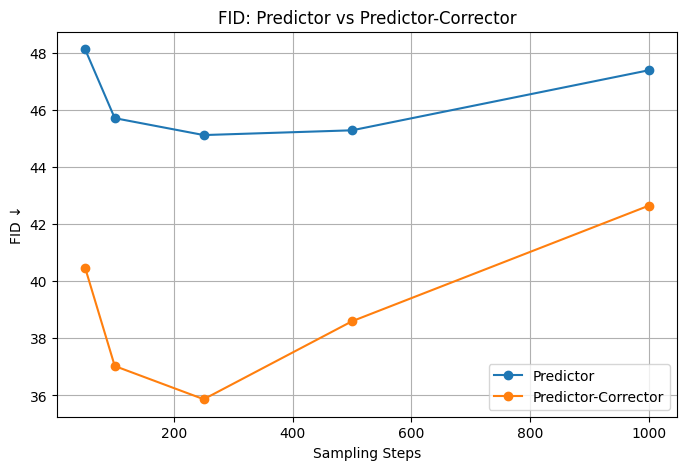

In [ ]:
# ============================================================
# FID COMPARISON
# ============================================================

import matplotlib.pyplot as plt

predictor_fid = [
    fid_results_dict[s]
    for s in PC_STEPS
]

pc_fid = [
    pc_fid_results[s]
    for s in PC_STEPS
]

plt.figure(figsize=(8, 5))

plt.plot(
    PC_STEPS,
    predictor_fid,
    marker="o",
    label="Predictor"
)

plt.plot(
    PC_STEPS,
    pc_fid,
    marker="o",
    label="Predictor-Corrector"
)

plt.xlabel("Sampling Steps")
plt.ylabel("FID ↓")
plt.title("FID: Predictor vs Predictor-Corrector")

plt.legend()
plt.grid(True)
plt.show()

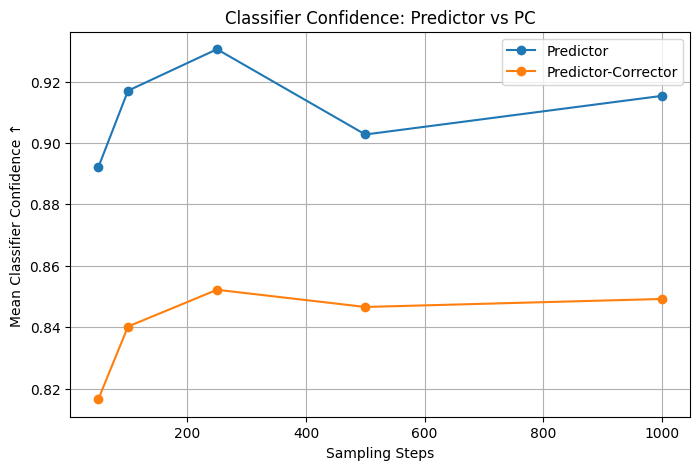

In [ ]:
# ============================================================
# CLASSIFIER CONFIDENCE COMPARISON
# ============================================================

predictor_conf = [
    mean_classifier_confidence_dict[s]
    for s in PC_STEPS
]

pc_conf = [
    pc_classifier_confidence[s]
    for s in PC_STEPS
]

plt.figure(figsize=(8, 5))

plt.plot(
    PC_STEPS,
    predictor_conf,
    marker="o",
    label="Predictor"
)

plt.plot(
    PC_STEPS,
    pc_conf,
    marker="o",
    label="Predictor-Corrector"
)

plt.xlabel("Sampling Steps")
plt.ylabel("Mean Classifier Confidence ↑")
plt.title(
    "Classifier Confidence: Predictor vs PC"
)

plt.legend()
plt.grid(True)
plt.show()

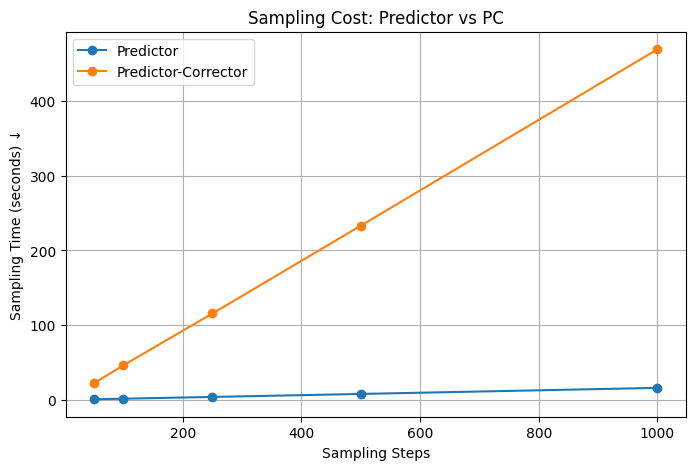

In [ ]:
# ============================================================
# SAMPLING TIME COMPARISON
# ============================================================

predictor_time = [
    sampling_times_dict[s]
    for s in PC_STEPS
]

pc_time = [
    pc_sampling_times[s]
    for s in PC_STEPS
]

plt.figure(figsize=(8, 5))

plt.plot(
    PC_STEPS,
    predictor_time,
    marker="o",
    label="Predictor"
)

plt.plot(
    PC_STEPS,
    pc_time,
    marker="o",
    label="Predictor-Corrector"
)

plt.xlabel("Sampling Steps")
plt.ylabel("Sampling Time (seconds) ↓")
plt.title(
    "Sampling Cost: Predictor vs PC"
)

plt.legend()
plt.grid(True)
plt.show()

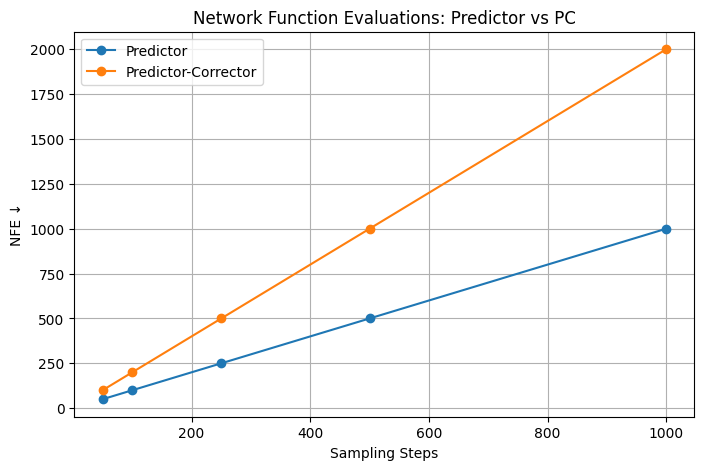

In [ ]:
# ============================================================
# NFE COMPARISON
# ============================================================

predictor_nfe = PC_STEPS

pc_nfe_values = [
    s * 2
    for s in PC_STEPS
]

plt.figure(figsize=(8, 5))

plt.plot(
    PC_STEPS,
    predictor_nfe,
    marker="o",
    label="Predictor"
)

plt.plot(
    PC_STEPS,
    pc_nfe_values,
    marker="o",
    label="Predictor-Corrector"
)

plt.xlabel("Sampling Steps")
plt.ylabel("NFE ↓")
plt.title(
    "Network Function Evaluations: Predictor vs PC"
)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# BEST RESULTS
# ============================================================

best_predictor_step = min(
    fid_results_dict,
    key=fid_results_dict.get
)

best_pc_step = min(
    pc_fid_results,
    key=pc_fid_results.get
)

print("=" * 60)
print("BEST RESULTS")
print("=" * 60)

print(
    f"Best Predictor: "
    f"P{best_predictor_step}"
)

print(
    f"FID = "
    f"{fid_results_dict[best_predictor_step]:.4f}"
)

print()

print(
    f"Best Predictor-Corrector: "
    f"PC{best_pc_step}"
)

print(
    f"FID = "
    f"{pc_fid_results[best_pc_step]:.4f}"
)

print()

improvement = (
    fid_results_dict[best_predictor_step]
    - pc_fid_results[best_pc_step]
)

print(
    f"FID difference = {improvement:.4f}"
)


BEST RESULTS
Best Predictor: P250
FID = 45.1138

Best Predictor-Corrector: PC250
FID = 35.8669

FID difference = 9.2469
